# House Price Prediction Analysis
### Name: Yash Lahase

---

## Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Task 1: Data Loading and Exploration

We load the dataset and understand its structure by examining its dimensions, columns, and missing values.

In [3]:
# Load file
df = pd.read_csv("Housing.csv")

# Display first 10 rows
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
# Dataset shape
print("Rows and Columns:", df.shape)

# Column names
print("Columns:")
print(df.columns.tolist())

Rows and Columns: (545, 13)
Columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [5]:
# Missing values
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

# Task 2: Data Cleaning

We ensures the dataset is suitable for machine learning by handling duplicates, missing values, and categorical variables.

In [6]:
# Remove duplicates
print("Duplicate Rows:", df.duplicated().sum())
# There are no duplicate values but for understanding we implemented the removal of duplicate values
df = df.drop_duplicates()

Duplicate Rows: 0


In [7]:
# Handle missing values for Integers columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Handle missing values for Categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [8]:
# Convert categorical variables
df = pd.get_dummies(df, drop_first=True)
df.head()
# We haven't removed any columns as the Housing.csv dataset does not contain such irrelevant columns for prediction

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


# Task 3: Model Building

Two regression models are developed:
1. Linear Regression
2. Random Forest Regressor

Their performances are then compared.

In [9]:
# Define features and target
X = df.drop("price", axis=1)
y = df["price"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Linear Regression

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

MAE: 970043.403920164
RMSE: 1324506.9600914388
R² Score: 0.6529242642153184


## Random Forest Regression

In [11]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


## Comparing Linear and Random Forest Regression

In [12]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R² Score": [lr_r2, rf_r2]
})
comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


# Task 4: Data Visualization

Visualizations help us understand patterns and relationships within the data.

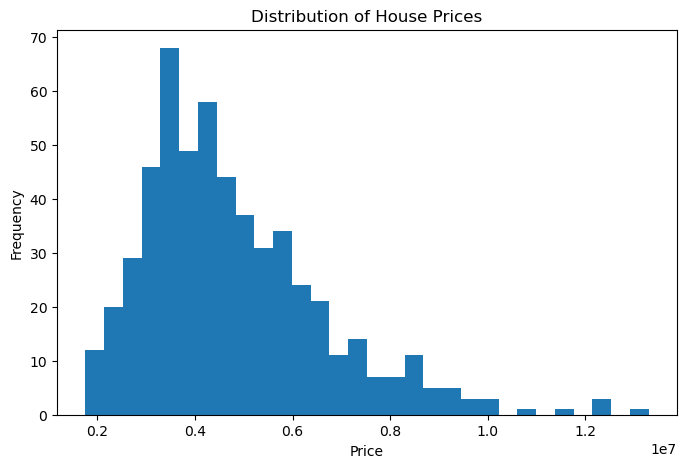

In [13]:
# Chart 1: Price Distribution
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=30)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.savefig("charts/price_distribution.png")
plt.show()

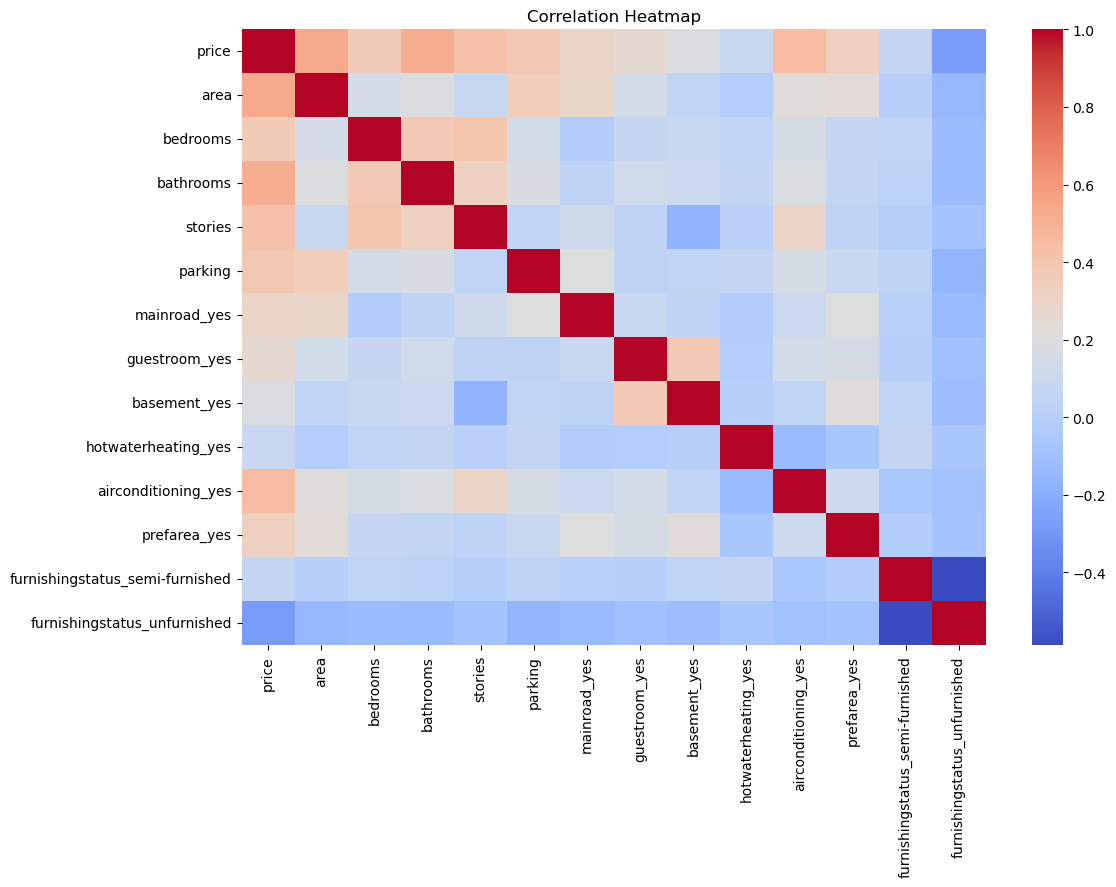

In [14]:
# Chart 2: Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("charts/correlation_heatmap.png")
plt.show()

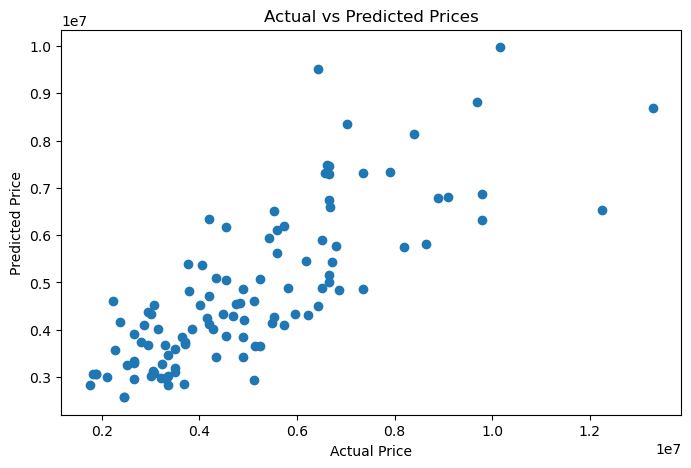

In [16]:
# Chart 3: Actual vs Predicted Prices
plt.figure(figsize=(8,5))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.savefig("charts/actual_vs_predicted.png")
plt.show()

# Task 5: Insights and Summary
## Sample Summary

The findings indicated that a home's size had the biggest impact on its price, implying that larger homes are more valuable. Price was positively correlated with other factors, such as the number of toilets, air conditioning, parking, and being in a desirable area. Because Random Forest Regressor produced a higher R2 score and reduced prediction errors (MAE and RMSE), it fared better than the Linear Regression model. It suggests that complex and non-linear connections determine home values.
# Conclusion

This project demonstrated the complete machine learning workflow, from data preprocessing to model evaluation. The findings provide valuable insights into property valuation and showcase how predictive analytics can support data driven decision making in real estate.